In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# -------------------------------
# PATHS
# -------------------------------
CSV_ROOT = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv"
IMG_ROOT = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg"

# -------------------------------
# LOAD TRAIN CSVs ONLY
# -------------------------------
calc_train = pd.read_csv(f"{CSV_ROOT}/calc_case_description_train_set.csv")
mass_train = pd.read_csv(f"{CSV_ROOT}/mass_case_description_train_set.csv")

df = pd.concat([calc_train, mass_train], ignore_index=True)

print("After merge:", len(df))

# -------------------------------
# CLEAN PATHOLOGY
# -------------------------------
df["pathology"] = df["pathology"].astype(str).str.strip().str.upper()

df = df[df["pathology"].isin([
    "BENIGN",
    "BENIGN_WITHOUT_CALLBACK",
    "MALIGNANT"
])]

df["label"] = df["pathology"].apply(
    lambda x: 0 if "BENIGN" in x else 1
)

print("After pathology filter:", len(df))
print("Patients:", df["patient_id"].nunique())

# -------------------------------
# BUILD IMAGE TABLE FROM UID
# -------------------------------
records = []

for _, row in df.iterrows():
    roi_path = row["ROI mask file path"]
    if not isinstance(roi_path, str):
        continue

    uid = os.path.basename(os.path.dirname(roi_path))
    uid_dir = os.path.join(IMG_ROOT, uid)

    if not os.path.isdir(uid_dir):
        continue

    for fname in os.listdir(uid_dir):
        if fname.endswith(".jpg"):
            records.append({
                "patient_id": row["patient_id"],
                "image_path": os.path.join(uid_dir, fname),
                "label": row["label"]
            })

img_df = pd.DataFrame(records)

print("Images found:", len(img_df))
print("Patients:", img_df["patient_id"].nunique())

# -------------------------------
# LIMIT TO 500 PATIENTS
# -------------------------------
patients = img_df["patient_id"].unique()
np.random.shuffle(patients)

patients_500 = patients[:500]
img_df = img_df[img_df["patient_id"].isin(patients_500)]

print("After 500 patient limit:", img_df["patient_id"].nunique())

# -------------------------------
# PATIENT-WISE SPLIT
# -------------------------------
patients = img_df["patient_id"].unique()

train_p, temp_p = train_test_split(patients, test_size=0.3, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

train_df = img_df[img_df["patient_id"].isin(train_p)]
val_df   = img_df[img_df["patient_id"].isin(val_p)]
test_df  = img_df[img_df["patient_id"].isin(test_p)]

assert len(set(train_df.patient_id) & set(test_df.patient_id)) == 0

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

# -------------------------------
# DATASET LOADER
# -------------------------------
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, (224, 224))
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, batch=16, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["image_path"].values, df["label"].values)
    )
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

# -------------------------------
# MODEL
# -------------------------------
base = tf.keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(base.input, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# TRAIN
# -------------------------------
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True
        )
    ]
)

# -------------------------------
# TEST
# -------------------------------
loss, acc = model.evaluate(test_ds)
print("Test accuracy:", acc)


2026-01-09 14:42:38.846801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767969759.040686      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767969759.099512      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767969759.566583      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767969759.566625      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767969759.566629      23 computation_placer.cc:177] computation placer alr

After merge: 2864
After pathology filter: 2864
Patients: 1248
Images found: 5633
Patients: 1248
After 500 patient limit: 500
Train images: 1494
Val images: 310
Test images: 295


I0000 00:00:1767969804.500357      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20


I0000 00:00:1767969817.408141      62 service.cc:152] XLA service 0x799de808d950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767969817.408180      62 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767969817.936237      62 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/94 ━━━━━━━━━━━━━━━━━━━━ 21:23 14s/step - accuracy: 0.6250 - loss: 0.6424

I0000 00:00:1767969823.258373      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 122ms/step - accuracy: 0.4925 - loss: 0.7472 - val_accuracy: 0.4645 - val_loss: 0.7091
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.5482 - loss: 0.7134 - val_accuracy: 0.4742 - val_loss: 0.7031
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.5504 - loss: 0.7055 - val_accuracy: 0.5226 - val_loss: 0.6874
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.5604 - loss: 0.7017 - val_accuracy: 0.5000 - val_loss: 0.6995
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.5867 - loss: 0.6808 - val_accuracy: 0.5290 - val_loss: 0.6887
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.5588 - loss: 0.6848 - val_accuracy: 0.5032 - val_loss: 0.7019
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.5128 - loss: 0.6920
Test accuracy: 0.511864423751831


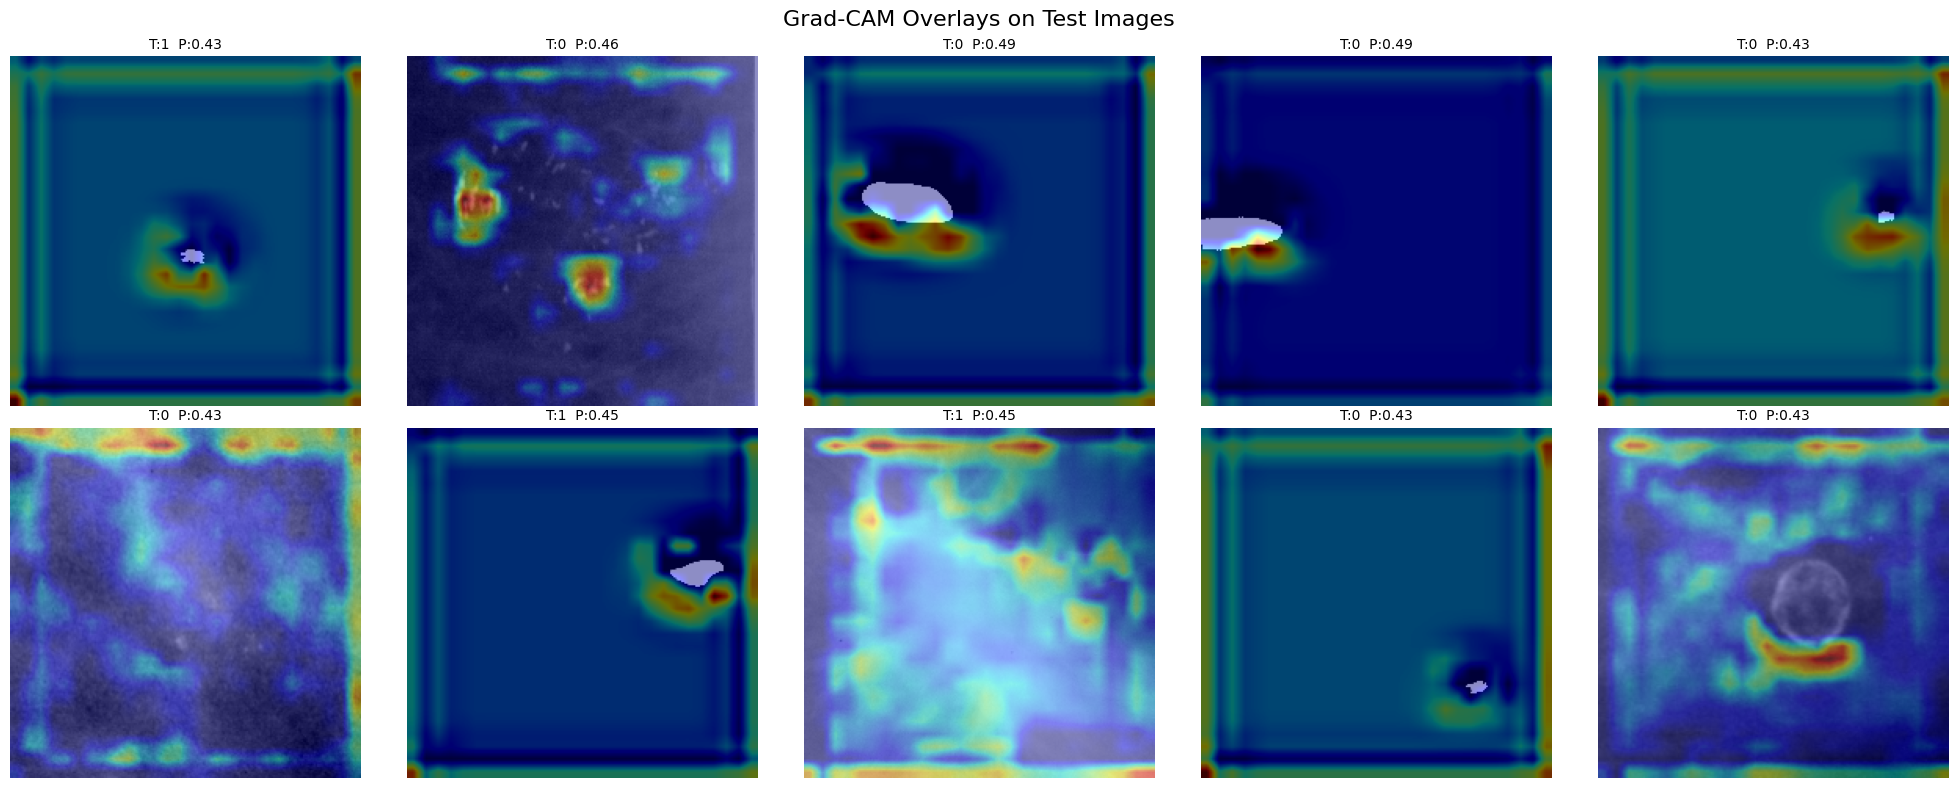

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# CONFIG
# --------------------------------
N = 10
last_conv_layer_name = "block4_conv3"

# --------------------------------
# IMAGE LOADER (SAME AS TRAINING)
# --------------------------------
def load_single_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, (224, 224))
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# --------------------------------
# GRAD-CAM MODEL
# --------------------------------
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

# --------------------------------
# SAMPLE 10 TEST IMAGES
# --------------------------------
samples = test_df.sample(N, random_state=42)

plt.figure(figsize=(20, 8))

for idx, row in enumerate(samples.itertuples(), 1):

    img = load_single_image(row.image_path)
    img_batch = tf.expand_dims(img, axis=0)

    # prediction
    pred = model.predict(img_batch, verbose=0)[0][0]

    # grad-cam
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap.numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()

    img_np = img.numpy().squeeze()

    plt.subplot(2, 5, idx)
    plt.imshow(img_np, cmap="gray")
    plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
    plt.axis("off")

    title = f"T:{row.label}  P:{pred:.2f}"
    plt.title(title, fontsize=10)

plt.suptitle("Grad-CAM Overlays on Test Images", fontsize=16)
plt.tight_layout()
plt.show()


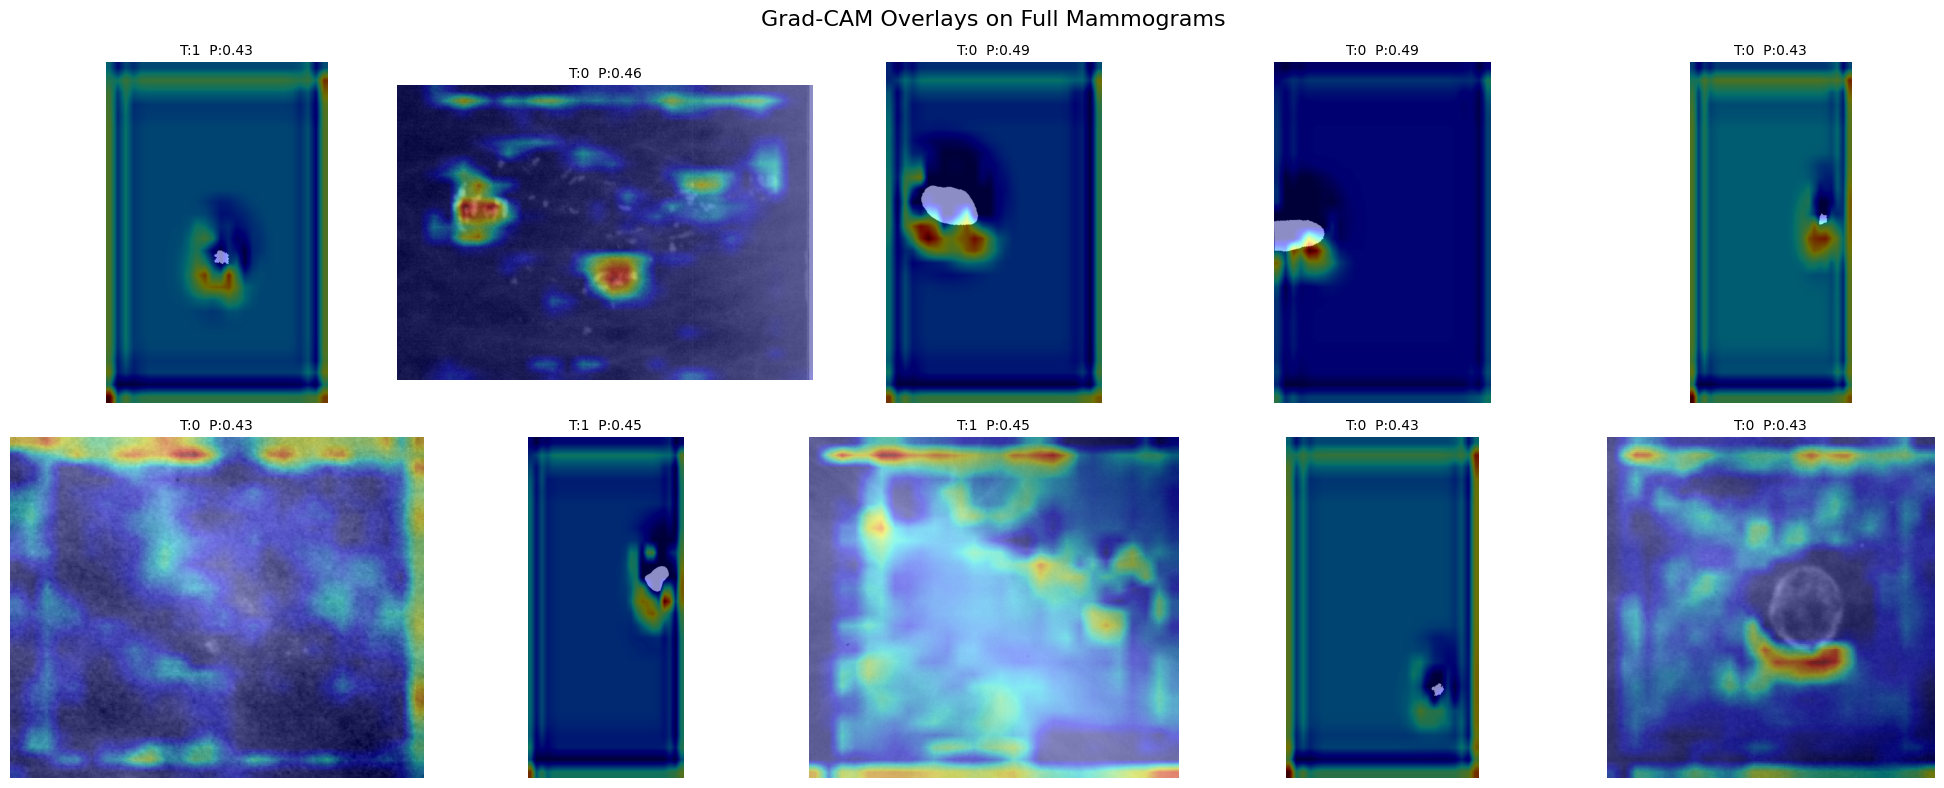

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# CONFIG
# --------------------------------
N = 10
last_conv_layer_name = "block4_conv3"

# --------------------------------
# IMAGE LOADER (keep original size)
# --------------------------------
def load_single_image(path):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_raw, channels=1)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def preprocess_for_model(img):
    # resize only for model input
    return tf.image.resize(img, (224, 224))

# --------------------------------
# GRAD-CAM MODEL
# --------------------------------
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

# --------------------------------
# SAMPLE 10 TEST IMAGES
# --------------------------------
samples = test_df.sample(N, random_state=42)

plt.figure(figsize=(20, 8))

for idx, row in enumerate(samples.itertuples(), 1):

    # load full mammogram
    img_full = load_single_image(row.image_path)
    h, w = img_full.shape[:2]

    # preprocess for model
    img_input = preprocess_for_model(img_full)
    img_batch = tf.expand_dims(img_input, axis=0)

    # prediction
    pred = model.predict(img_batch, verbose=0)[0][0]

    # grad-cam
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap.numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # resize heatmap back to full mammogram size
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (h, w)
    ).numpy().squeeze()

    img_np = img_full.numpy().squeeze()

    plt.subplot(2, 5, idx)
    plt.imshow(img_np, cmap="gray")
    plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
    plt.axis("off")

    title = f"T:{row.label}  P:{pred:.2f}"
    plt.title(title, fontsize=10)

plt.suptitle("Grad-CAM Overlays on Full Mammograms", fontsize=16)
plt.tight_layout()
plt.show()
